# RFM Segmentation
**Answers:** C5 (and supports C1-C4) · Notes: P3 - RFM Segmentation
**Input:** `reports/tables/orders_clean.csv` (from `data_cleaning.ipynb`)

| Metric | Definition |
| --- | --- |
| Recency | days from the customer's last delivered order to the reference date |
| Frequency | number of delivered orders |
| Monetary | total revenue (price + freight) of the customer's delivered orders |
| Reference date | the day after the last purchase in the data (the data is historical - "today" would make every customer look lost) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.3f}".format)

RAW = Path("../data/raw")
TABLES = Path("../reports/tables")
FIGS = Path("../reports/figures")
TABLES.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

In [2]:
# Chart style: recessive grid/axes, thin marks, text in neutral ink (never series colour)
BLUE, ORANGE = "#2a78d6", "#eb6834"      # on-time / main series = blue, late = orange (validated pair)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False,
    "font.size": 10,
})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight")
    print("saved", FIGS / name)

## 1. Build the RFM table
One row per `customer_unique_id`, whole order history (2016-09 .. 2018-08).

In [3]:
orders = pd.read_csv(TABLES / "orders_clean.csv", parse_dates=["purchase_date", "purchase_month"])

REFERENCE_DATE = orders["purchase_date"].max() + pd.Timedelta(days=1)
print("reference date:", REFERENCE_DATE.date())

rfm = (orders.groupby("customer_unique_id")
             .agg(last_purchase=("purchase_date", "max"),
                  frequency=("order_id", "nunique"),
                  monetary=("revenue", "sum")))
rfm["recency"] = (REFERENCE_DATE - rfm["last_purchase"]).dt.days
rfm = rfm[["recency", "frequency", "monetary"]]
print(rfm.shape)
rfm.head()

reference date: 2018-08-30
(93358, 3)


,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.900
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.190
0000f46a3911fa3c0805444483337064,538,1,86.220
0000f6ccb0745a6a4b88665a16c9f078,322,1,43.620
0004aac84e0df4da2b147fca70cf8255,289,1,196.890


## 2. Distributions
**Question:** what do R, F and M look like? What share of customers has F = 1, 2, 3+?

In [4]:
rfm.describe(percentiles=[.2, .4, .5, .6, .8, .9]).T

,count,mean,std,min,20%,40%,50%,60%,80%,90%,max
recency,"93,358.000",238.479,152.595,1.000,93.000,178.000,219.000,269.000,383.000,466.000,714.000
frequency,"93,358.000",1.033,0.209,1.000,1.000,1.000,1.000,1.000,1.000,1.000,15.000
monetary,"93,358.000",165.218,226.332,9.590,55.254,87.360,107.790,132.690,208.550,318.074,"13,664.080"


In [5]:
f_dist = rfm["frequency"].clip(upper=3).map({1: "1", 2: "2", 3: "3+"}).value_counts().sort_index()
pd.DataFrame({"customers": f_dist, "pct": 100 * f_dist / f_dist.sum()})

,customers,pct
frequency,,
1,90557,97.000
2,2573,2.756
3+,228,0.244


In [6]:
# Why quintiles cannot work for Frequency: the quintile edges collapse onto the same value
print("F quintile edges:", rfm["frequency"].quantile([0, .2, .4, .6, .8, 1]).tolist())
try:
    pd.qcut(rfm["frequency"], 5)
except ValueError as e:
    print("pd.qcut on frequency fails:", e)

F quintile edges: [1.0, 1.0, 1.0, 1.0, 1.0, 15.0]
pd.qcut on frequency fails: Bin edges must be unique: Index([1.0, 1.0, 1.0, 1.0, 1.0, 15.0], dtype='float64', name='frequency').
You can drop duplicate edges by setting the 'duplicates' kwarg


saved ../reports/figures/rfm_distributions.png


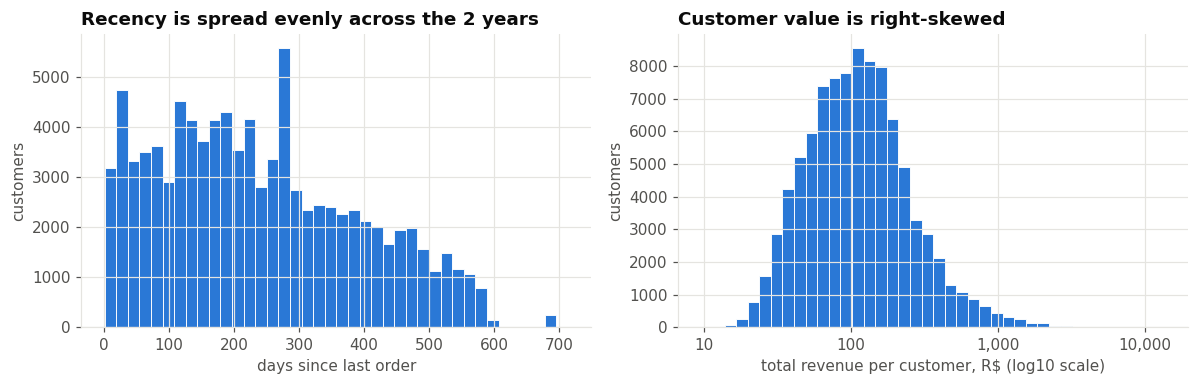

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(rfm["recency"], bins=40, color=BLUE, edgecolor="white", linewidth=0.6)
axes[0].set_title("Recency is spread evenly across the 2 years")
axes[0].set_xlabel("days since last order"); axes[0].set_ylabel("customers")
axes[1].hist(np.log10(rfm["monetary"]), bins=40, color=BLUE, edgecolor="white", linewidth=0.6)
axes[1].set_title("Customer value is right-skewed")
axes[1].set_xlabel("total revenue per customer, R$ (log10 scale)"); axes[1].set_ylabel("customers")
ticks = [1, 2, 3, 4]
axes[1].set_xticks(ticks, [f"{10**t:,}" for t in ticks])
fig.tight_layout()
save(fig, "rfm_distributions.png")

**Finding:** 97.0% of customers ordered once, 2.8% twice and 0.2% three or more times, so Frequency cannot be split into quintiles (4 of 5 quintile edges are 1). Monetary is right-skewed (median R$ 107.79, max R$ 13,664); recency is spread fairly evenly over two years.

## 3. Scoring method (decision)

| Metric | Method | Bins | Why |
| --- | --- | --- | --- |
| R | quintiles (`pd.qcut`, 5 = most recent) | 20% of customers per score | recency has many distinct values and no natural business thresholds |
| F | **rule-based** | 1 order -> 1 · 2 orders -> 2 · 3+ orders -> 3 | quintiles are impossible: the vast majority of customers have exactly 1 order (see step 2) |
| M | quintiles (`pd.qcut`, 5 = highest value) | 20% of customers per score | skewed but continuous - quantiles are robust to the skew |

In [8]:
R_LABELS = [5, 4, 3, 2, 1]          # low recency (recent) = best
M_LABELS = [1, 2, 3, 4, 5]
F_BINS, F_LABELS = [0, 1, 2, np.inf], [1, 2, 3]

rfm["R"] = pd.qcut(rfm["recency"], 5, labels=R_LABELS).astype(int)
rfm["F"] = pd.cut(rfm["frequency"], bins=F_BINS, labels=F_LABELS).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=M_LABELS).astype(int)

# thresholds actually used - visible for the methodology document
print("R quintile edges (days):", rfm["recency"].quantile([.2, .4, .6, .8]).round(0).tolist())
print("M quintile edges (R$):  ", rfm["monetary"].quantile([.2, .4, .6, .8]).round(2).tolist())
rfm[["R", "F", "M"]].apply(pd.Series.value_counts).fillna(0).astype(int)

R quintile edges (days): [93.0, 178.0, 269.0, 383.0]
M quintile edges (R$):   [55.25, 87.36, 132.69, 208.55]


,R,F,M
1,18605,90557,18672
2,18471,2573,18678
3,18723,228,18670
4,18757,0,18667
5,18802,0,18671


## 4. Segment rules
Because most customers are one-time buyers, a single "One-time Customers" segment would hold almost everyone and give marketing nothing to act on. The one-time base is therefore split by **recency** and **value** - the two things that decide whether a second-purchase campaign is worth sending.

| Segment | Rule | Business meaning | Possible action |
| --- | --- | --- | --- |
| Champions | F >= 2 and R >= 4 | bought more than once, recently | VIP treatment, referrals, early access |
| Loyal Customers | F >= 2 and R <= 3 | bought more than once, but not recently | win-back with a personal offer |
| Potential Loyalists | F = 1 and R >= 4 and M >= 4 | one recent, high-value first order | **main target for the second-purchase campaign** |
| Recent One-time | F = 1 and R >= 4 and M <= 3 | one recent, smaller first order | low-cost nudge (cross-sell email) |
| At Risk | F = 1 and R in {2, 3} and M >= 4 | valuable first order, drifting away | reactivation offer before they are lost |
| One-time Lapsed | every other F = 1 customer | old, lower-value single order | no spend; include only in cheap mass channels |

Rules are evaluated top to bottom, so every customer gets exactly one segment.

In [9]:
def assign_segment(row):
    if row.F >= 2 and row.R >= 4:
        return "Champions"
    if row.F >= 2:
        return "Loyal Customers"
    if row.R >= 4 and row.M >= 4:
        return "Potential Loyalists"
    if row.R >= 4:
        return "Recent One-time"
    if row.R in (2, 3) and row.M >= 4:
        return "At Risk"
    return "One-time Lapsed"

SEGMENT_ORDER = ["Champions", "Loyal Customers", "Potential Loyalists",
                 "Recent One-time", "At Risk", "One-time Lapsed"]
rfm["segment"] = pd.Categorical(rfm.apply(assign_segment, axis=1), categories=SEGMENT_ORDER, ordered=True)

# completeness check: every customer exactly one segment
assert rfm["segment"].notna().all()
assert len(rfm) == orders["customer_unique_id"].nunique()
print("all", len(rfm), "customers have exactly one segment")

all 93358 customers have exactly one segment


## 5. Segment profile
**Question:** how big is each segment, how much revenue does it bring, and how does it behave?

In [10]:
profile = (rfm.groupby("segment", observed=True)
              .agg(customers=("R", "size"), revenue=("monetary", "sum"),
                   avg_orders=("frequency", "mean"), avg_recency_days=("recency", "mean"),
                   avg_monetary=("monetary", "mean"),
                   repeat_rate=("frequency", lambda f: (f >= 2).mean())))
profile["pct_customers"] = 100 * profile["customers"] / profile["customers"].sum()
profile["pct_revenue"] = 100 * profile["revenue"] / profile["revenue"].sum()
profile["repeat_rate"] = 100 * profile["repeat_rate"]
profile = profile[["customers", "pct_customers", "revenue", "pct_revenue", "avg_orders",
                   "avg_recency_days", "avg_monetary", "repeat_rate"]]
profile.round(2)

,customers,pct_customers,revenue,pct_revenue,avg_orders,avg_recency_days,avg_monetary,repeat_rate
segment,,,,,,,,
Champions,1214,1.300,"391,038.460",2.540,2.150,90.030,322.110,100.000
Loyal Customers,1587,1.700,"473,916.160",3.070,2.080,320.850,298.620,100.000
Potential Loyalists,14503,15.530,"4,382,691.820",28.410,1.000,92.470,302.190,0.000
Recent One-time,21842,23.400,"1,593,164.530",10.330,1.000,90.770,72.940,0.000
At Risk,13823,14.810,"4,068,866.910",26.380,1.000,269.220,294.350,0.000
One-time Lapsed,40389,43.260,"4,514,785.770",29.270,1.000,361.490,111.780,0.000


In [11]:
# Revenue concentration: what share of revenue comes from the top 10% / 20% of customers?
m_sorted = rfm["monetary"].sort_values(ascending=False)
for top in (0.1, 0.2):
    n = int(len(m_sorted) * top)
    print(f"top {int(top*100)}% of customers -> {100 * m_sorted.iloc[:n].sum() / m_sorted.sum():.1f}% of revenue")

top 10% of customers -> 38.3% of revenue
top 20% of customers -> 53.5% of revenue


In [12]:
# Do segments differ in where customers live? (share of the 3 largest states)
seg_state = orders.merge(rfm[["segment"]], left_on="customer_unique_id", right_index=True)
seg_state = seg_state.drop_duplicates("customer_unique_id")    # state of the customer's first listed order
(pd.crosstab(seg_state["segment"], seg_state["customer_state"], normalize="index")[["SP", "RJ", "MG"]] * 100).round(1)

customer_state,SP,RJ,MG
segment,,,
Champions,46.800,14.000,11.000
Loyal Customers,41.300,13.900,11.900
Potential Loyalists,38.800,12.400,11.800
Recent One-time,49.700,11.100,11.000
At Risk,34.600,14.600,12.400
One-time Lapsed,41.200,13.000,12.000


## 6. Chart: share of customers vs share of revenue

saved ../reports/figures/rfm_segments_customers_vs_revenue.png


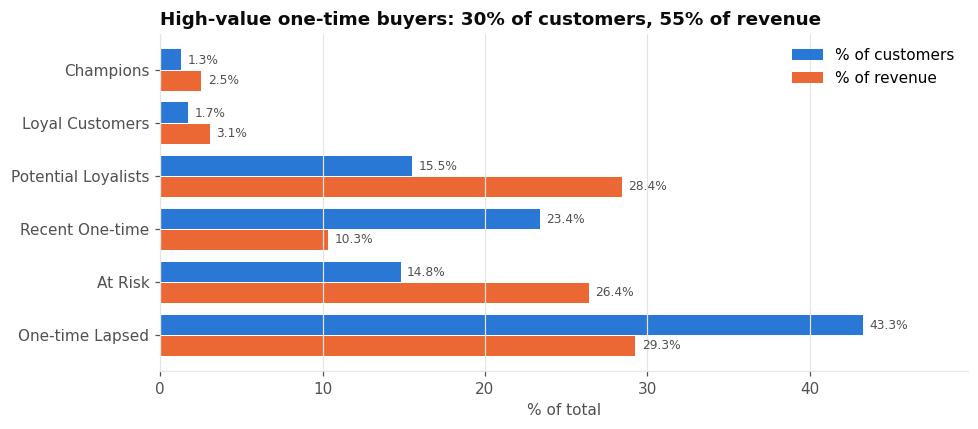

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(profile))
h = 0.38
ax.barh(y - h/2 - 0.01, profile["pct_customers"], height=h, color=BLUE, label="% of customers")
ax.barh(y + h/2 + 0.01, profile["pct_revenue"], height=h, color=ORANGE, label="% of revenue")
for yi, (c_, r_) in enumerate(zip(profile["pct_customers"], profile["pct_revenue"])):
    ax.text(c_ + 0.4, yi - h/2, f"{c_:.1f}%", va="center", fontsize=8, color=INK2)
    ax.text(r_ + 0.4, yi + h/2, f"{r_:.1f}%", va="center", fontsize=8, color=INK2)
ax.set_yticks(y, profile.index)
ax.invert_yaxis()
ax.set_xlabel("% of total")
ax.grid(axis="y", visible=False)
hv = profile.loc[["Potential Loyalists", "At Risk"]]
ax.set_title(f"High-value one-time buyers: {hv['pct_customers'].sum():.0f}% of customers, "
             f"{hv['pct_revenue'].sum():.0f}% of revenue")
ax.set_xlim(0, max(profile["pct_customers"].max(), profile["pct_revenue"].max()) * 1.15)
ax.legend(loc="upper right")
fig.tight_layout()
save(fig, "rfm_segments_customers_vs_revenue.png")

**Finding:** Repeat buyers (Champions + Loyal Customers) are only 3.0% of customers and 5.6% of revenue. High-value one-time buyers (Potential Loyalists + At Risk) are 30.3% of customers but 54.8% of revenue. Revenue is concentrated: the top 20% of customers bring 53.5% of revenue. The state mix of the segments is similar (SP 35-50% everywhere), so geography does not separate them.

## 7. Export for Power BI

In [14]:
rfm.reset_index().to_csv(TABLES / "rfm_segments.csv", index=False)
print("saved", TABLES / "rfm_segments.csv", rfm.shape)

saved ../reports/tables/rfm_segments.csv (93358, 7)


## Conclusion (C5)

Classic RFM is **weak in this dataset** because Frequency hardly varies - in practice this is an **R x M segmentation** of one-time buyers plus a small repeat group. That is itself a finding: the business has almost no loyal base to segment.
It is still useful for action: 28,326 high-value one-time customers (Potential Loyalists 14,503 recent + At Risk 13,823 older) hold 54.8% of revenue and are the natural target for a second-purchase campaign; the 40,389 One-time Lapsed customers are the lowest priority.
Limitation: the segment thresholds are quintiles of this dataset, not business-validated values; the segments describe past behaviour and do not predict who will buy again.